In [ ]:
import uproot
import pandas as pd
import numpy as np

MAIN_CAF = "/storage/1/st15719/caf_new_sum.2.6M_weighted.root"
PFP_FILE = "reco_pfp_info.root"

Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

caf_tree = uproot.open(MAIN_CAF)["cafTree"]
data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

initial_count = len(data[PDG])
print(f"Initial entries in CAF file: {initial_count}")

df_kinematics = pd.DataFrame({
    'Enu_e_had': [x[0] if len(x) > 0 else np.nan for x in data[Enu_e_had]],
    'Enu_e_calo': [x[0] if len(x) > 0 else np.nan for x in data[Enu_e_calo]],
    'Enu_mu_had': [x[0] if len(x) > 0 else np.nan for x in data[Enu_mu_had]],
    'Enu_mu_range': [x[0] if len(x) > 0 else np.nan for x in data[Enu_mu_range]],
})

df_kinematics['pdg'] = data[PDG]
df_kinematics['inelasticity_e'] = 1 -( (df_kinematics['Enu_e_had'] / df_kinematics['Enu_e_calo']) )
df_kinematics['inelasticity_mu'] = 1 -( (df_kinematics['Enu_mu_had'] / df_kinematics['Enu_mu_range']) )
df_kinematics['label'] = (df_kinematics['pdg'] < 0).astype(int)

pfp_tree = uproot.open(PFP_FILE)["reco_pfp_tree"]
df_pfps = pfp_tree.arrays(library="pd")

df_final = pd.concat([df_kinematics, df_pfps], axis=1)

count_pre_filter = len(df_final)

df_final = df_final[df_final['reco_ok'] == True]
count_after_reco_check = len(df_final)
print(f"Entries discarded by reco_ok filter: {count_pre_filter - count_after_reco_check}")


Initial entries in CAF file: 2884703
Entries discarded by reco_ok filter: 233676

Final DataFrame contains 2651027 events.


KeyError: "['E_nu', 'hadron_energy', 'inelasticity'] not in index"

In [22]:
df_final = df_final.drop(columns= ['reco_ok','Enu_e_had', 'Enu_e_calo', 'Enu_mu_had', 'Enu_mu_range'])
df_final

,pdg,inelasticity_e,inelasticity_mu,label,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
0,-12,0.564708,0.018015,1,10,5,4,11.487990,4,1
1,-12,0.519653,0.689843,1,2,1,0,0.110940,1,0
2,-14,0.735094,0.745076,1,4,3,0,0.064570,2,1
4,14,0.823313,0.850355,0,3,2,0,0.002420,1,1
5,16,0.988919,0.988908,0,2,1,0,0.003319,1,0
...,...,...,...,...,...,...,...,...,...,...
2884698,14,1.000000,1.000000,0,2,1,0,0.000000,1,0
2884699,14,0.984981,0.990219,0,2,1,0,0.005397,1,0
2884700,14,0.887005,0.932367,0,3,1,1,0.012165,1,0
2884701,12,0.959213,0.086923,0,3,1,1,0.102556,0,1


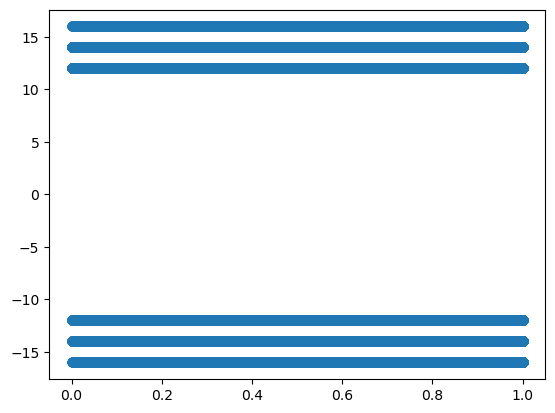

In [31]:
import matplotlib.pyplot as plt

plt.plot(df_final['inelasticity_e'], df_final['pdg'], 'o', alpha=0.5)